# Cutom CNN

## 2. Added class-imbalance handling:
#### - Calculated per-class sample counts using the training set.  
#### - Created inverse-frequency **class weights** and added them to`CrossEntropyLoss`. 
#### - Enabled `label_smoothing=0.1` to make predictions less overconfident across 44 classes.  
#### - Added a **WeightedRandomSampler** so training batches are balanced across classes.

## 3. Improved optimization and training stability:
#### - Used Adam with **weight decay (L2 regularization)** to prevent overfitting.  
#### - Added a **ReduceLROnPlateau** learning-rate scheduler that lowers LR when validation loss stops improving.  
#### - Kept and improved early stopping to prevent unnecessary long training.

## 4. Clean evaluation utilities: 
#### - Used helper functions for accuracy, confusion matrices, ROC curves, and inference time.  
#### - Ensured training/validation/test metrics are recorded clearly as before.


Training Custom CNN (from scratch)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[CustomCNN_v2] Epoch 01/100 | Train Loss: 3.7854 Acc: 0.0610 | Val Loss: 5.2028 Acc: 0.0168
[CustomCNN_v2] Epoch 02/100 | Train Loss: 3.1994 Acc: 0.0889 | Val Loss: 5.0707 Acc: 0.0338
[CustomCNN_v2] Epoch 03/100 | Train Loss: 2.9495 Acc: 0.1243 | Val Loss: 4.7718 Acc: 0.0497
[CustomCNN_v2] Epoch 04/100 | Train Loss: 2.7836 Acc: 0.1573 | Val Loss: 4.7651 Acc: 0.0643
[CustomCNN_v2] Epoch 05/100 | Train Loss: 2.6555 Acc: 0.1762 | Val Loss: 4.8417 Acc: 0.0592
[CustomCNN_v2] Epoch 06/100 | Train Loss: 2.5249 Acc: 0.2040 | Val Loss: 4.7331 Acc: 0.0927
[CustomCNN_v2] Epoch 07/100 | Train Loss: 2.4538 Acc: 0.2194 | Val Loss: 4.4248 Acc: 0.1170
[CustomCNN_v2] Epoch 08/100 | Train Loss: 2.3788 Acc: 0.2420 | Val Loss: 4.3576 Acc: 0.1484
[CustomCNN_v2] Epoch 09/100 | Train Loss: 2.2772 Acc: 0.2718 | Val Loss: 4.4440 Acc: 0.1229
[CustomCNN_v2] Epoch 10/100 | Train Loss: 2.2414 Acc: 0.2913 | Val Loss: 4.2847 Acc: 0.1597
[CustomCNN_v2] Epoch 11/100 | Train Loss: 2.1240 Acc: 0.3135 | Val Loss: 4.2921 

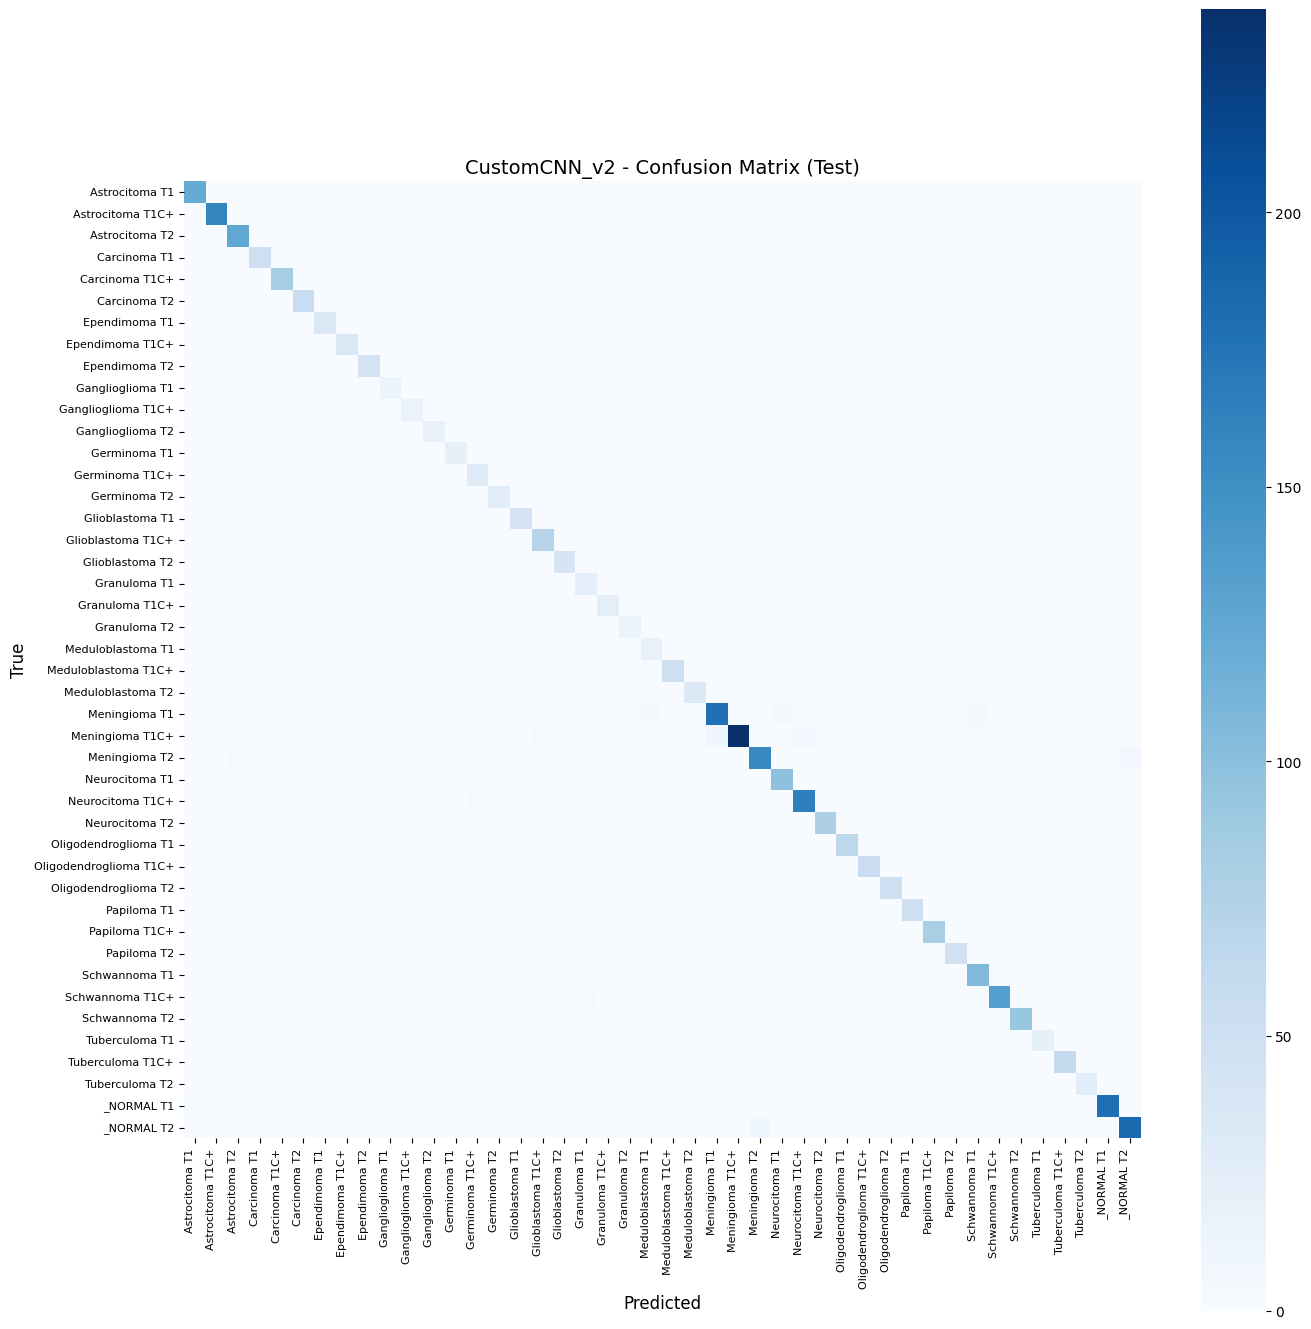

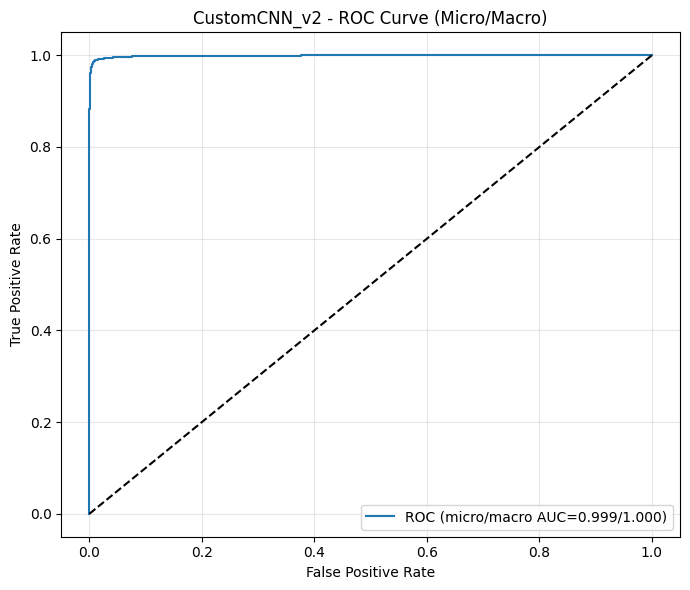

Macro AUC: 0.9996 | Micro AUC: 0.9990

[CustomCNN_v2] Timing:
Training time: 9605.93 s
Testing time: 6.72 s
Average inference time per image: 4.58 ms



In [13]:
import os, time, random, numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
data_root = "/kaggle/working/brain-tumor-mri-split"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "val")
test_dir  = os.path.join(data_root, "test")

# Transforms (same style as your original)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
img_size = 224

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Datasets
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)

batch_size = 32
num_workers = 2
pin_memory = torch.cuda.is_available()

# Class weights (for loss) and sample weights (for sampler)
class_counts = Counter(train_ds.targets)
num_samples = len(train_ds)

class_weights = [num_samples / class_counts[i] for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

sample_weights = [class_weights[label] for label in train_ds.targets]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Dataloaders
train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=pin_memory
)

val_loader = torch.utils.data.DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

# Loss (class-weighted + label smoothing)
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)

def print_model_summary(m, input_size=(1, 3, img_size, img_size)):
    try:
        from torchinfo import summary
        print(summary(m, input_size=input_size,
                      col_names=("input_size","output_size","num_params","trainable")))
    except Exception:
        print(m)
        total_params = sum(p.numel() for p in m.parameters())
        trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"Total params: {total_params:,}")
        print(f"Trainable params: {trainable_params:,}")

# ---- Custom CNN (updated) ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p_drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Dropout2d(p=p_drop),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,    32, p_drop=0.0),  # 224 -> 112
            ConvBlock(32,   64, p_drop=0.0),  # 112 -> 56
            ConvBlock(64,  128, p_drop=0.1),  # 56  -> 28
            ConvBlock(128, 256, p_drop=0.2),  # 28  -> 14
            ConvBlock(256, 512, p_drop=0.3),  # 14  -> 7
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

def run_epoch(model, loader, optimizer=None, train_mode=True):
    model.train() if train_mode else model.eval()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = running_correct / max(total, 1)
    return epoch_loss, epoch_acc

@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds

@torch.no_grad()
def collect_preds_and_probs(model, loader):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds)
        all_targets.append(targets.numpy())
    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds, all_probs

@torch.no_grad()
def measure_inference_time(model, dataset, max_samples=100):
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    indices = indices[:min(max_samples, len(indices))]
    single_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, indices),
        batch_size=1, shuffle=False, num_workers=0, pin_memory=pin_memory
    )
    if device.type == "cuda":
        torch.cuda.empty_cache()
    for i, (x, _) in enumerate(single_loader):
        x = x.to(device)
        _ = model(x)
        if i >= 5:
            break
    start = time.time()
    for x, _ in single_loader:
        x = x.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end = time.time()
    n = len(indices)
    return (end - start) / n if n > 0 else float("nan")

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    plt.figure(figsize=(14, 14))
    sns.heatmap(cm, cmap="Blues", cbar=True, square=True,
                xticklabels=labels, yticklabels=labels,
                annot=False)
    plt.xticks(rotation=90, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_roc_auc(y_true, y_prob, labels, title):
    y_true_bin = label_binarize(y_true, classes=list(range(len(labels))))
    macro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    micro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="micro")
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC (micro/macro AUC={micro_auc:.3f}/{macro_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Macro AUC: {macro_auc:.4f} | Micro AUC: {micro_auc:.4f}")

def train_and_evaluate(model, model_name, epochs, patience, lr, weight_decay):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=2, verbose=True
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    t_train_start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, train_mode=True)
        val_loss, val_acc = run_epoch(model, val_loader, train_mode=False)
        scheduler.step(val_loss)

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{model_name}] Early stopping at epoch {epoch}.")
                break

    t_train_end = time.time()
    train_time_s = t_train_end - t_train_start

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    print(f"\n[{model_name}] Model summary (post-training):")
    print_model_summary(model)

    print(f"\n[{model_name}] Classification report - TRAIN:")
    y_true_tr, y_pred_tr = collect_preds(model, train_loader)
    print(classification_report(y_true_tr, y_pred_tr, target_names=class_names,
                                zero_division=0, digits=4))

    print(f"\n[{model_name}] Classification report - VAL:")
    y_true_va, y_pred_va = collect_preds(model, val_loader)
    print(classification_report(y_true_va, y_pred_va, target_names=class_names,
                                zero_division=0, digits=4))

    print(f"\n[{model_name}] Classification report - TEST:")
    t_test_start = time.time()
    y_true_te, y_pred_te, y_prob_te = collect_preds_and_probs(model, test_loader)
    t_test_end = time.time()
    test_time_s = t_test_end - t_test_start
    print(classification_report(y_true_te, y_pred_te, target_names=class_names,
                                zero_division=0, digits=4))

    plot_confusion_matrix(y_true_te, y_pred_te, class_names,
                          f"{model_name} - Confusion Matrix (Test)")

    plot_roc_auc(y_true_te, y_prob_te, class_names,
                 f"{model_name} - ROC Curve (Micro/Macro)")

    avg_inf_s = measure_inference_time(model, test_ds, max_samples=100)

    print(f"\n[{model_name}] Timing:")
    print(f"Training time: {train_time_s:.2f} s")
    print(f"Testing time: {test_time_s:.2f} s")
    print(f"Average inference time per image: {avg_inf_s*1000:.2f} ms\n")

    return model

print("\nTraining Custom CNN (from scratch)")
custom_cnn = CustomCNN(num_classes=num_classes)
custom_cnn = train_and_evaluate(
    model=custom_cnn,
    model_name="CustomCNN_v2",
    epochs=100,
    patience=7,
    lr=1e-3,
    weight_decay=1e-4
)
